# 00: Environment and Library Tour

We start the EconML tutorial series. The goal is to make sure the local environment works, introduce the main EconML estimator families, and create a small synthetic CATE sandbox that later notebooks can reuse.

EconML is strongest when the causal question is already clear and the hard part is estimating treatment effects with modern machine learning. In particular, it is useful for:

- estimating heterogeneous treatment effects;
- using flexible nuisance models for outcomes and treatment assignment;
- comparing DML, doubly robust, forest, and meta-learner approaches;
- ranking units by expected treatment benefit;
- turning CATE estimates into treatment-targeting policies.

This lesson is intentionally broad. Later notebooks go deeper into each estimator family.

## Orientation and Learning Goals

By the end, you should be able to:

- Verify that EconML imports successfully in this environment.
- Identify the major EconML estimator families and when each one is useful.
- Understand the standard EconML data roles: outcome `Y`, treatment `T`, controls `W`, and effect modifiers `X`.
- Build a reusable synthetic dataset with known CATE ground truth.
- Run a small `LinearDML` smoke test to confirm the installation can fit an estimator.
- Read the output of a CATE workflow without confusing it for a graph-identification workflow.

## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

This tutorial is an orientation to `EconML`, so the examples are deliberately compact. They are not meant to settle an applied causal question. They are meant to show how the package represents data, models, graphs, estimands, estimators, diagnostics, and saved outputs before the later notebooks use richer designs.

When a small dataset appears here, read it as a smoke test for the workflow rather than as evidence about a real population. The important experiment is procedural: can the environment run, can the objects be created, and can the reader see where assumptions will enter in later notebooks?


## Mathematical Foundation

<!-- math-foundation-note -->

EconML is built around conditional treatment effects. For binary treatment,

$$
\tau(x)=\mathbb{E}\{Y(1)-Y(0)\mid X=x\}.
$$

The average treatment effect is

$$
\tau_{ATE}=\mathbb{E}\{\tau(X)\}.
$$

The estimators differ in how they learn nuisance functions, represent $\tau(x)$, and quantify uncertainty. The causal assumptions come from the design.





## EconML Orientation and Setup

### EconML in One Sentence

EconML is an estimation library for treatment effects, especially **conditional average treatment effects**.

A concise mental model:

- Use graph-first workflow tools to clarify assumptions and identification.
- Use EconML when you need flexible treatment-effect estimation after the causal question is defined.

This lesson focuses on the estimation layer: how the package is organized, how data should be shaped, and how the first estimator call behaves.

### Setup

The code below imports the core packages, sets warning filters, creates output folders, and records whether EconML is available. The warning filters are scoped to common notebook noise so real execution errors still appear.

In [1]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import os
import warnings
import importlib.metadata as importlib_metadata

# Keep Matplotlib cache files in a writable location during notebook execution.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-ranking-sys")

warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", message=".*X does not have valid feature names.*")
warnings.filterwarnings("ignore", message=".*The final model has a nonzero intercept.*")
warnings.filterwarnings("ignore", module="sklearn.linear_model._logistic")

import numpy as np

# Compatibility shim for older SHAP/EconML imports under NumPy 2.x.
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_
if not hasattr(np, "obj2sctype"):
    def _numpy_obj2sctype_compat(rep, default=None):
        try:
            return np.dtype(rep).type
        except TypeError:
            return default

    np.obj2sctype = _numpy_obj2sctype_compat
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import roc_auc_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

try:
    import econml
    ECONML_AVAILABLE = True
    ECONML_VERSION = getattr(econml, "__version__", "unknown")
except Exception as exc:
    ECONML_AVAILABLE = False
    ECONML_VERSION = f"import failed: {type(exc).__name__}: {exc}"

RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)

OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print(f"EconML available: {ECONML_AVAILABLE}")
print(f"EconML version: {ECONML_VERSION}")
print(f"Figures will be saved to: {FIGURE_DIR.resolve()}")
print(f"Tables will be saved to: {TABLE_DIR.resolve()}")


EconML available: True
EconML version: 0.16.0
Figures will be saved to: /home/apex/Documents/portfolio/notebooks/tutorials/econml/outputs/figures
Tables will be saved to: /home/apex/Documents/portfolio/notebooks/tutorials/econml/outputs/tables


The import check confirms that EconML is usable in this environment. All saved outputs from this lesson use the `00_` prefix.

This is a reproducibility check rather than causal evidence. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->


### Package Versions

A causal ML notebook depends on several libraries working together. We record versions so future debugging has a clear starting point.

In [2]:
# Save the artifacts produced by the Package Versions section.
packages_to_check = [
    "python",
    "econml",
    "numpy",
    "pandas",
    "scikit-learn",
    "scipy",
    "statsmodels",
    "matplotlib",
    "seaborn",
]

version_rows = []
for package in packages_to_check:
    if package == "python":
        import sys
        version = sys.version.split()[0]
    else:
        try:
            version = importlib_metadata.version(package)
        except importlib_metadata.PackageNotFoundError:
            version = "not installed"
    version_rows.append({"package": package, "version": version})

package_versions = pd.DataFrame(version_rows)
package_versions.to_csv(TABLE_DIR / "00_environment_package_versions.csv", index=False)
display(package_versions)


,package,version
0,python,3.11.15
1,econml,0.16.0
2,numpy,2.4.4
3,pandas,3.0.2
4,scikit-learn,1.6.1
5,scipy,1.17.1
6,statsmodels,0.14.6
7,matplotlib,3.10.9
8,seaborn,0.13.2


This table is boring in exactly the right way. If a later estimator behaves differently after dependency changes, this snapshot gives us something concrete to compare against.

### EconML Capability Check

Next we check whether the major estimator classes import successfully. This is a lightweight environment test, not a claim that every estimator is appropriate for every dataset.

In [3]:
# Save the artifacts produced by the EconML Capability Check section.
estimator_import_specs = [
    ("LinearDML", "econml.dml", "LinearDML"),
    ("SparseLinearDML", "econml.dml", "SparseLinearDML"),
    ("CausalForestDML", "econml.dml", "CausalForestDML"),
    ("DRLearner", "econml.dr", "DRLearner"),
    ("ForestDRLearner", "econml.dr", "ForestDRLearner"),
    ("SLearner", "econml.metalearners", "SLearner"),
    ("TLearner", "econml.metalearners", "TLearner"),
    ("XLearner", "econml.metalearners", "XLearner"),
    ("DMLIV", "econml.iv.dml", "DMLIV"),
]

capability_rows = []
for friendly_name, module_name, class_name in estimator_import_specs:
    try:
        module = __import__(module_name, fromlist=[class_name])
        estimator_class = getattr(module, class_name)
        status = "available"
        detail = estimator_class.__name__
    except Exception as exc:
        status = "not available"
        detail = f"{type(exc).__name__}: {exc}"
    capability_rows.append(
        {
            "estimator": friendly_name,
            "module": module_name,
            "status": status,
            "detail": detail,
        }
    )

capability_table = pd.DataFrame(capability_rows)
capability_table.to_csv(TABLE_DIR / "00_econml_capability_check.csv", index=False)
display(capability_table)


IPython could not be loaded!


,estimator,module,status,detail
0,LinearDML,econml.dml,available,LinearDML
1,SparseLinearDML,econml.dml,available,SparseLinearDML
2,CausalForestDML,econml.dml,available,CausalForestDML
3,DRLearner,econml.dr,available,DRLearner
4,ForestDRLearner,econml.dr,available,ForestDRLearner
5,SLearner,econml.metalearners,available,SLearner
6,TLearner,econml.metalearners,available,TLearner
7,XLearner,econml.metalearners,available,XLearner
8,DMLIV,econml.iv.dml,available,DMLIV


The core estimator families are available. That means later notebooks can use the real EconML package instead of fallback examples.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


## Estimator Families and Data Roles

EconML has many estimators. The practical choice usually starts with the treatment type, the desired amount of flexibility, and whether you need direct interpretability or nonlinear CATE discovery.

| family | examples | best for | main output |
| --- | --- | --- | --- |
| DML estimators | LinearDML, SparseLinearDML, CausalForestDML | CATE with observed confounding and flexible nuisance models | treatment-effect function tau(X) |
| Doubly robust learners | DRLearner, ForestDRLearner | binary or categorical treatment with outcome and propensity nuisance models | CATE estimates with doubly robust pseudo-outcomes |
| Meta-learners | SLearner, TLearner, XLearner | simple, flexible baselines for heterogeneous effects | CATE from outcome-model contrasts |
| IV estimators | DMLIV, DeepIV, OrthoIV | endogenous treatment with a valid instrument | effect estimates identified by instrument variation |
| Policy tools | policy learning utilities and CATE ranking workflows | turning CATE estimates into treatment allocation rules | targeting rule or policy-value comparison |


This map is the first decision aid for the series. The next notebooks unpack these rows one by one with runnable examples.

The table is useful because it compresses the evidence into a form that can be compared, audited, and tied back to the causal question.
<!-- result-implication-expanded -->


### Standard EconML Data Roles

EconML estimators use a consistent vocabulary. The most important distinction is between controls `W` and effect modifiers `X`.

| symbol | role | plain meaning | example in this lesson |
| --- | --- | --- | --- |
| Y | outcome | The result measured after treatment. | outcome |
| T | treatment | The intervention or exposure whose effect we estimate. | treatment |
| W | controls / confounders | Variables used to adjust nuisance models but not necessarily describe heterogeneity. | account_tenure |
| X | effect modifiers | Variables used to model how the treatment effect changes across units. | baseline_need, prior_engagement, friction_score, high_need_segment |
| tau(X) | CATE function | The conditional average treatment effect for units with features X. | true_cate and estimated_cate |


The `X` versus `W` split matters. `X` describes where effects vary; `W` helps remove confounding in the nuisance models.

The causal implication is indirect but important: these diagnostics tell us whether the modeling stage is stable enough to support the causal estimate.
<!-- result-implication-expanded -->


### Workflow Map

A typical EconML analysis has a repeatable shape. This map gives the flow that later notebooks will use.

| step | question | artifact |
| --- | --- | --- |
| Frame causal question | What is the treatment, outcome, population, and estimand? | causal question table |
| Prepare data roles | Which columns are Y, T, X, and W? | role map and design matrices |
| Check overlap | Do treated and control units have comparable covariates? | propensity and balance diagnostics |
| Choose estimator | Do we need linear CATE, nonlinear CATE, DR learning, or IV logic? | estimator selection rationale |
| Fit nuisance models and CATE model | Are outcome and treatment processes modeled well enough for this task? | fitted EconML estimator |
| Validate CATE behavior | Do estimated effects rank, segment, and average sensibly? | calibration, segment, and ranking diagnostics |
| Report decision summary | What should someone do differently, and what assumptions could break it? | report-ready summary |


The estimator call is only one part of the workflow. The diagnostics and reporting steps are what keep a CATE model from becoming a black box with causal language attached.

## Smoke-Test Dataset Design

We now create a synthetic dataset with observed confounding and known heterogeneous treatment effects. Known truth is a teaching luxury: it lets us check whether an estimator is learning the right pattern.

In [4]:
N = 3_000

baseline_need = rng.normal(0, 1, size=N)
prior_engagement = rng.normal(0, 1, size=N)
account_tenure = rng.normal(0, 1, size=N)
friction_score = rng.normal(0, 1, size=N)
high_need_segment = (baseline_need > 0).astype(int)

# Observational treatment assignment. Treatment is not randomized.
propensity = 1 / (1 + np.exp(-(
    -0.20
    + 0.70 * baseline_need
    + 0.45 * prior_engagement
    - 0.30 * account_tenure
    + 0.35 * friction_score
)))
treatment = rng.binomial(1, propensity, size=N)

# Heterogeneous treatment effect. This is known only because the data are synthetic.
true_cate = (
    0.50
    + 0.35 * high_need_segment
    + 0.20 * prior_engagement
    - 0.15 * friction_score
)

outcome = (
    true_cate * treatment
    + 0.60 * baseline_need
    + 0.35 * prior_engagement
    - 0.25 * account_tenure
    - 0.30 * friction_score
    + rng.normal(0, 0.75, size=N)
)

teaching_df = pd.DataFrame(
    {
        "baseline_need": baseline_need,
        "prior_engagement": prior_engagement,
        "account_tenure": account_tenure,
        "friction_score": friction_score,
        "high_need_segment": high_need_segment,
        "treatment": treatment,
        "outcome": outcome,
        "propensity": propensity,
        "true_cate": true_cate,
    }
)

teaching_df.to_csv(TABLE_DIR / "00_teaching_dataset.csv", index=False)
display(teaching_df.head())


,baseline_need,prior_engagement,account_tenure,friction_score,high_need_segment,treatment,outcome,propensity,true_cate
0,-0.7931,-0.4520,0.3610,1.5171,0,0,-2.0808,0.3691,0.1820
1,0.2406,-0.3531,-1.0970,-0.6711,1,1,2.0381,0.4760,0.8800
2,-1.8963,-0.9423,-0.4935,0.9219,0,1,-1.3458,0.1853,0.1733
3,1.3958,0.0110,0.4890,0.1365,1,1,0.8205,0.6644,0.8317
4,0.6383,1.1904,-0.5878,1.5456,1,1,2.8091,0.8175,0.8563


The dataset has the ingredients needed for a first EconML tour: binary treatment, continuous outcome, observed confounding, and treatment effects that vary by features.

### Data Dictionary

The next table documents each column and how it should be used. Later notebooks will reuse this pattern for their own example data.

| column | role | plain meaning | included in |
| --- | --- | --- | --- |
| baseline_need | effect modifier and confounder | Pre-treatment need or intent. | X |
| prior_engagement | effect modifier and confounder | Historical engagement before treatment. | X |
| account_tenure | control confounder | Pre-treatment account maturity. | W |
| friction_score | effect modifier and confounder | Pre-treatment friction or difficulty. | X |
| high_need_segment | effect modifier | Binary segment derived from baseline need. | X |
| treatment | binary treatment | Whether the unit received the intervention. | T |
| outcome | outcome | Post-treatment outcome to improve. | Y |
| propensity | known treatment probability for learning | True assignment probability from the simulator. | diagnostics only |
| true_cate | known treatment-effect truth for learning | Unit-level conditional effect from the simulator. | diagnostics only |


The last two columns would not exist in real data. They are included here only so the tutorial can check whether estimators recover the known effect pattern.




## Smoke-Test Results and Takeaways

#### Basic Dataset Summary

Before fitting anything, summarize treatment rate, outcome scale, and the true CATE distribution. This gives us a baseline expectation for later estimator outputs.

In [5]:
teaching_summary = pd.DataFrame(
    [
        {"quantity": "rows", "value": len(teaching_df)},
        {"quantity": "treatment_rate", "value": teaching_df["treatment"].mean()},
        {"quantity": "outcome_mean", "value": teaching_df["outcome"].mean()},
        {"quantity": "outcome_std", "value": teaching_df["outcome"].std()},
        {"quantity": "true_ate", "value": teaching_df["true_cate"].mean()},
        {"quantity": "true_cate_std", "value": teaching_df["true_cate"].std()},
        {"quantity": "true_cate_min", "value": teaching_df["true_cate"].min()},
        {"quantity": "true_cate_max", "value": teaching_df["true_cate"].max()},
    ]
)

teaching_summary.to_csv(TABLE_DIR / "00_teaching_summary.csv", index=False)
display(teaching_summary)


,quantity,value
0,rows,"3,000.0000"
1,treatment_rate,0.4430
2,outcome_mean,0.3326
3,outcome_std,1.3039
4,true_ate,0.6802
5,true_cate_std,0.3048
6,true_cate_min,-0.3644
7,true_cate_max,1.6742


The true effect is positive on average, but it varies across units. That variation is exactly what EconML is designed to estimate.

The later estimates should be read in light of this sample construction, since data quality and composition set the boundary for any causal claim.
<!-- result-implication-expanded -->




#### True CATE Distribution

Because this is synthetic data, we can plot the true CATE. In real data, this plot would be replaced by estimated CATE diagnostics.

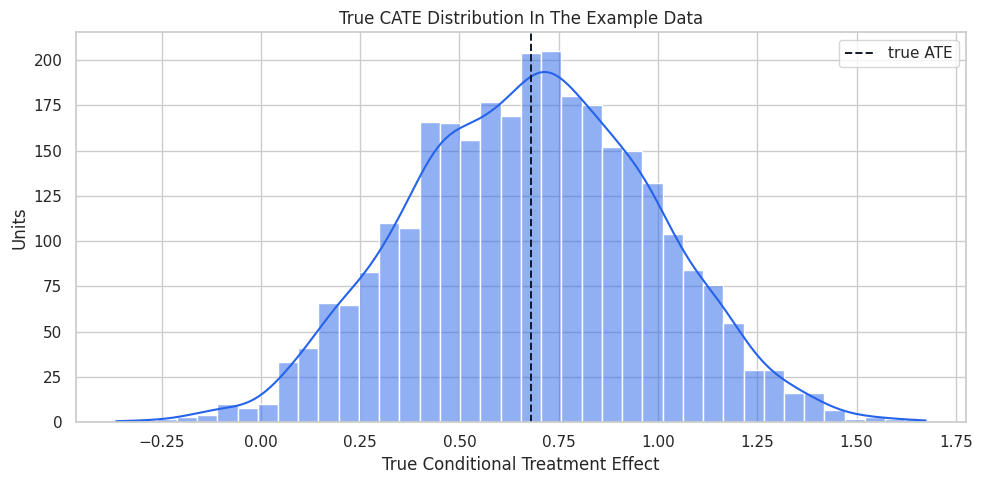

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(teaching_df, x="true_cate", bins=40, kde=True, color="#2563eb", ax=ax)
ax.axvline(teaching_df["true_cate"].mean(), color="#111827", linestyle="--", linewidth=1.4, label="true ATE")
ax.set_title("True CATE Distribution In The Example Data")
ax.set_xlabel("True Conditional Treatment Effect")
ax.set_ylabel("Units")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "00_true_cate_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

The distribution shows why a single ATE is incomplete. Some units have much larger expected benefit than others.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->


### Treatment Assignment Diagnostics

Treatment is observational in this example data. We check whether pre-treatment features differ between treated and control groups.

In [7]:
# Define reusable helpers for the Treatment Assignment Diagnostics section.
FEATURE_COLUMNS = ["baseline_need", "prior_engagement", "account_tenure", "friction_score", "high_need_segment"]
X_COLUMNS = ["baseline_need", "prior_engagement", "friction_score", "high_need_segment"]
W_COLUMNS = ["account_tenure"]
TREATMENT_COLUMN = "treatment"
OUTCOME_COLUMN = "outcome"


def standardized_mean_difference(data, column, treatment_col=TREATMENT_COLUMN):
    """
    Idea: Measure covariate imbalance as a treated-control mean difference on a pooled-standard-deviation scale.
    
    Parameters
    ----------
    data : array-like or pd.DataFrame
        Data passed into the demonstrated method.
    column : object
        Column name selected from the DataFrame for this calculation.
    treatment_col : str
        Name of the treatment or intervention column.
    
    Returns
    -------
    float
        Covariate-balance statistic on a pooled-standard-deviation scale.
    """
    treated = data.loc[data[treatment_col] == 1, column]
    control = data.loc[data[treatment_col] == 0, column]
    pooled_sd = np.sqrt((treated.var(ddof=1) + control.var(ddof=1)) / 2)
    return (treated.mean() - control.mean()) / pooled_sd if pooled_sd > 0 else 0.0

balance_table = pd.DataFrame(
    [
        {
            "feature": column,
            "control_mean": teaching_df.loc[teaching_df[TREATMENT_COLUMN] == 0, column].mean(),
            "treated_mean": teaching_df.loc[teaching_df[TREATMENT_COLUMN] == 1, column].mean(),
            "standardized_mean_difference": standardized_mean_difference(teaching_df, column),
        }
        for column in FEATURE_COLUMNS
    ]
).sort_values("standardized_mean_difference", key=lambda values: values.abs(), ascending=False)

balance_table.to_csv(TABLE_DIR / "00_treatment_balance_table.csv", index=False)
display(balance_table)


,feature,control_mean,treated_mean,standardized_mean_difference
0,baseline_need,-0.2887,0.2957,0.6044
4,high_need_segment,0.3980,0.6178,0.4505
1,prior_engagement,-0.1242,0.2195,0.3482
2,account_tenure,0.1397,-0.1827,-0.3254
3,friction_score,-0.1483,0.1688,0.3204


The groups are imbalanced, which means a raw difference in outcomes would not be a clean causal estimate. EconML estimators still need a credible adjustment design.

#### Plot Treatment Imbalance

The plot uses standardized mean differences so all features share the same scale. The dashed lines at `+/-0.1` are rough balance guides.

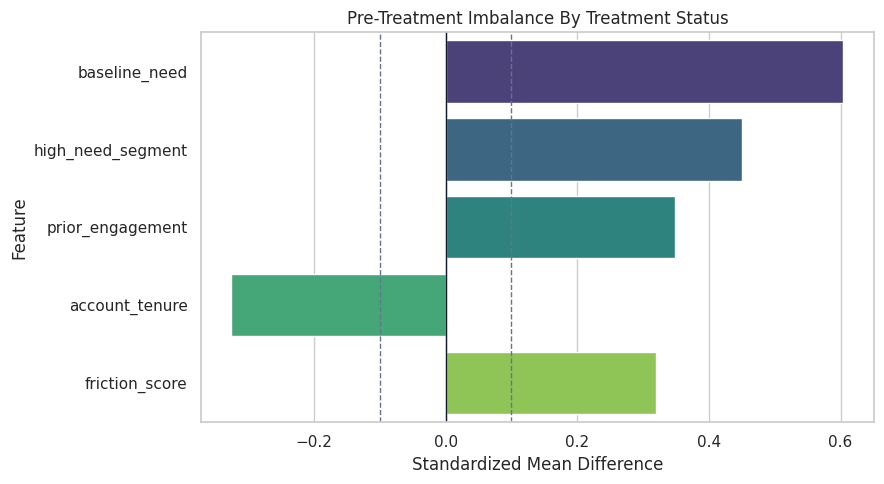

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=balance_table,
    x="standardized_mean_difference",
    y="feature",
    hue="feature",
    dodge=False,
    palette="viridis",
    legend=False,
    ax=ax,
)
ax.axvline(0, color="#111827", linewidth=1)
ax.axvline(0.1, color="#64748b", linestyle="--", linewidth=1)
ax.axvline(-0.1, color="#64748b", linestyle="--", linewidth=1)
ax.set_title("Pre-Treatment Imbalance By Treatment Status")
ax.set_xlabel("Standardized Mean Difference")
ax.set_ylabel("Feature")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "00_treatment_balance.png", dpi=160, bbox_inches="tight")
plt.show()


The imbalance is deliberate. This gives the EconML estimators real nuisance-model work to do instead of estimating effects from randomized treatment.

The causal implication is indirect but important: these diagnostics tell us whether the modeling stage is stable enough to support the causal estimate.
<!-- result-implication-expanded -->


### Propensity Overlap Check

Overlap matters for CATE estimation. If treatment assignment is nearly deterministic in some region, the estimator has little evidence for the missing treatment state there.

In [9]:
propensity_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1_000, solver="lbfgs"),
)
propensity_model.fit(teaching_df[FEATURE_COLUMNS], teaching_df[TREATMENT_COLUMN])
teaching_df["estimated_propensity"] = propensity_model.predict_proba(teaching_df[FEATURE_COLUMNS])[:, 1]

propensity_auc = roc_auc_score(teaching_df[TREATMENT_COLUMN], teaching_df["estimated_propensity"])
propensity_diagnostics = teaching_df["estimated_propensity"].describe().to_frame("estimated_propensity").reset_index()
propensity_diagnostics = propensity_diagnostics.rename(columns={"index": "summary"})
propensity_diagnostics.loc[len(propensity_diagnostics)] = {"summary": "roc_auc", "estimated_propensity": propensity_auc}

propensity_diagnostics.to_csv(TABLE_DIR / "00_propensity_diagnostics.csv", index=False)
print(f"Propensity model ROC AUC: {propensity_auc:.3f}")
display(propensity_diagnostics)


Propensity model ROC AUC: 0.735


,summary,estimated_propensity
0,count,"3,000.0000"
1,mean,0.4430
2,std,0.2019
3,min,0.0292
4,25%,0.2866
5,50%,0.4290
6,75%,0.5883
7,max,0.9799
8,roc_auc,0.7346


The propensity model is predictive, which confirms observational assignment. The next plot checks whether treated and control units still overlap enough to compare.

For causal interpretation, this is a support check: weak overlap can make an estimator depend on extrapolation instead of comparable treated and control units.
<!-- result-implication-expanded -->


#### Plot Propensity Overlap

A healthy CATE workflow should inspect overlap before trusting individualized or segment-level effects.

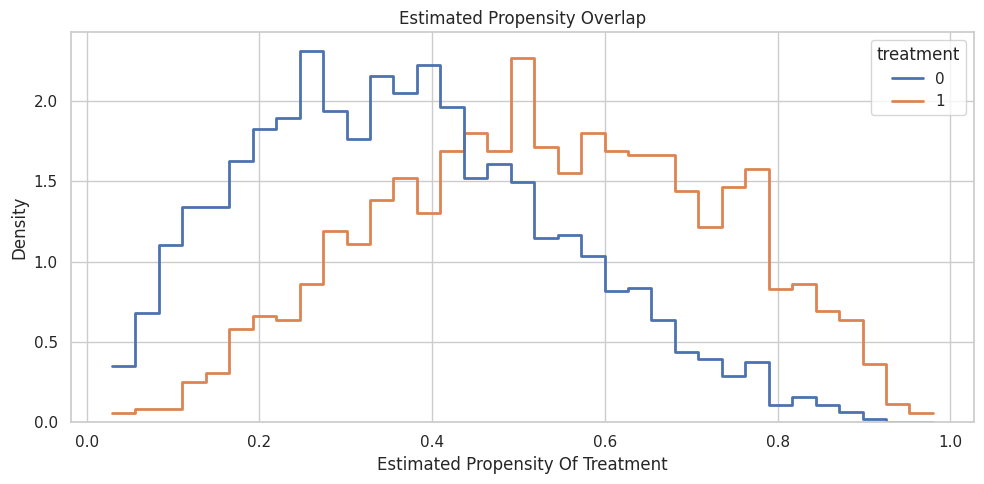

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=teaching_df,
    x="estimated_propensity",
    hue="treatment",
    bins=35,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    linewidth=2,
    ax=ax,
)
ax.set_title("Estimated Propensity Overlap")
ax.set_xlabel("Estimated Propensity Of Treatment")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "00_propensity_overlap.png", dpi=160, bbox_inches="tight")
plt.show()


The overlap is usable for a worked example. There are treated and control units across much of the propensity range, though the tails still deserve caution.



#### Train/Test Split for the Smoke Test

We split the data so the first EconML estimator is evaluated on rows it did not fit. This serves a different role than a full benchmark. It is better than only checking in-sample output.

In [11]:
train_idx, test_idx = train_test_split(
    np.arange(len(teaching_df)),
    test_size=0.35,
    random_state=RANDOM_SEED,
    stratify=teaching_df[TREATMENT_COLUMN],
)

split_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "rows": len(train_idx),
            "treatment_rate": teaching_df.iloc[train_idx][TREATMENT_COLUMN].mean(),
            "true_ate": teaching_df.iloc[train_idx]["true_cate"].mean(),
        },
        {
            "split": "test",
            "rows": len(test_idx),
            "treatment_rate": teaching_df.iloc[test_idx][TREATMENT_COLUMN].mean(),
            "true_ate": teaching_df.iloc[test_idx]["true_cate"].mean(),
        },
    ]
)

split_summary.to_csv(TABLE_DIR / "00_train_test_split_summary.csv", index=False)
display(split_summary)


,split,rows,treatment_rate,true_ate
0,train,1950,0.4431,0.6758
1,test,1050,0.4429,0.6882


The train and test splits have similar treatment rates and true ATE values. That makes the smoke-test metrics easier to read.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->


### LinearDML Smoke Test

`LinearDML` is a good first estimator because it uses nuisance models for treatment and outcome, then fits a linear final-stage treatment-effect model over `X`. The code below proves the environment can fit an actual EconML estimator.

In [12]:
# Fit or evaluate the model objects used in the LinearDML Smoke Test section.
from econml.dml import LinearDML

Y = teaching_df[OUTCOME_COLUMN].to_numpy()
T = teaching_df[TREATMENT_COLUMN].to_numpy()
X = teaching_df[X_COLUMNS].to_numpy()
W = teaching_df[W_COLUMNS].to_numpy()

linear_dml = LinearDML(
    model_y=RandomForestRegressor(
        n_estimators=80,
        min_samples_leaf=20,
        random_state=RANDOM_SEED,
    ),
    model_t=RandomForestClassifier(
        n_estimators=80,
        min_samples_leaf=20,
        random_state=RANDOM_SEED,
    ),
    discrete_treatment=True,
    cv=3,
    random_state=RANDOM_SEED,
)

linear_dml.fit(
    Y[train_idx],
    T[train_idx],
    X=X[train_idx],
    W=W[train_idx],
)

estimated_cate_test = linear_dml.effect(X[test_idx])
estimated_ate_test = linear_dml.ate(X[test_idx])
print(f"Estimated test ATE from LinearDML: {estimated_ate_test:.4f}")


Estimated test ATE from LinearDML: 0.7452


The estimator fit and produced an ATE. That confirms the core EconML workflow is operational in this environment.

This is a reproducibility check rather than causal evidence. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->




### Smoke-Test Metrics Against Known Truth

Because the synthetic data include `true_cate`, we can check whether the first estimator learned the broad effect pattern. These metrics are a teaching diagnostic, not something available in real data.

In [13]:
# Save the artifacts produced by the Smoke-Test Metrics Against Known Truth section.
true_cate_test = teaching_df.iloc[test_idx]["true_cate"].to_numpy()

smoke_metrics = pd.DataFrame(
    [
        {
            "metric": "test true ATE",
            "value": true_cate_test.mean(),
            "reading": "average ground-truth CATE in the test split",
        },
        {
            "metric": "LinearDML estimated ATE",
            "value": float(estimated_ate_test),
            "reading": "average estimated CATE in the test split",
        },
        {
            "metric": "CATE correlation with truth",
            "value": float(np.corrcoef(estimated_cate_test, true_cate_test)[0, 1]),
            "reading": "ranking alignment between estimated and true CATE",
        },
        {
            "metric": "CATE RMSE",
            "value": float(np.sqrt(mean_squared_error(true_cate_test, estimated_cate_test))),
            "reading": "average estimation error on the CATE scale",
        },
    ]
)

smoke_metrics.to_csv(TABLE_DIR / "00_lineardml_smoke_metrics.csv", index=False)
display(smoke_metrics)


,metric,value,reading
0,test true ATE,0.6882,average ground-truth CATE in the test split
1,LinearDML estimated ATE,0.7452,average estimated CATE in the test split
2,CATE correlation with truth,0.9738,ranking alignment between estimated and true CATE
3,CATE RMSE,0.0900,average estimation error on the CATE scale


The CATE correlation is the main smoke-test signal here: the estimator is learning the ranking pattern in the heterogeneous effects. Later notebooks will improve and compare estimators more systematically.



#### Inspect Predicted CATE Rows

A few row-level examples make the output tangible. The estimated CATE is model output; the true CATE is visible only because this is a synthetic tutorial.

In [14]:
cate_preview = teaching_df.iloc[test_idx][X_COLUMNS + ["true_cate"]].copy().reset_index(drop=True)
cate_preview["estimated_cate"] = estimated_cate_test
cate_preview["cate_error"] = cate_preview["estimated_cate"] - cate_preview["true_cate"]

cate_preview_head = cate_preview.head(12)
cate_preview_head.to_csv(TABLE_DIR / "00_lineardml_cate_preview.csv", index=False)
display(cate_preview_head)

,baseline_need,prior_engagement,friction_score,high_need_segment,true_cate,estimated_cate,cate_error
0,-0.0855,0.9274,-0.0889,0,0.6988,0.7915,0.0927
1,-0.5410,0.4251,0.7785,0,0.4682,0.5288,0.0606
2,0.1697,-0.6120,-1.3132,1,0.9246,1.0005,0.0760
3,1.9228,0.1040,-1.6990,1,1.1257,1.1747,0.0490
4,-0.0217,0.8017,0.7188,0,0.5525,0.6050,0.0525
5,0.6802,0.4975,-0.7995,1,1.0694,1.1222,0.0528
6,0.5616,1.2061,0.2121,1,1.0594,1.0804,0.0210
7,-0.3917,-1.4153,-2.0218,0,0.5202,0.6761,0.1559
8,0.9033,0.1863,-1.3424,1,1.0886,1.1545,0.0659
9,0.5673,0.3492,-0.5620,1,1.0041,1.0476,0.0435


The row preview shows what EconML gives you: an estimated treatment effect for each feature row. Those row-level estimates should be summarized carefully rather than treated as perfect individual truths.

#### Plot Estimated versus True CATE

The scatter plot checks whether high true-effect units tend to receive high estimated effects. This is a stronger diagnostic than only comparing ATE values.

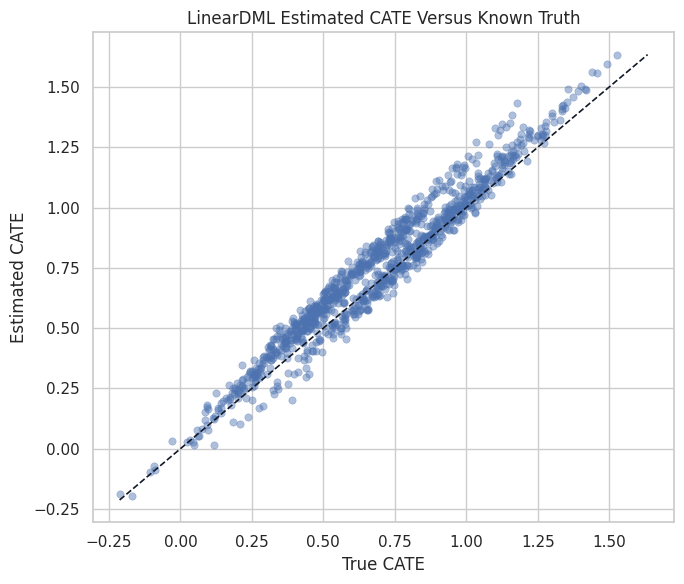

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(
    x=true_cate_test,
    y=estimated_cate_test,
    s=28,
    alpha=0.45,
    edgecolor=None,
    ax=ax,
)
min_value = min(true_cate_test.min(), estimated_cate_test.min())
max_value = max(true_cate_test.max(), estimated_cate_test.max())
ax.plot([min_value, max_value], [min_value, max_value], color="#111827", linestyle="--", linewidth=1.2)
ax.set_title("LinearDML Estimated CATE Versus Known Truth")
ax.set_xlabel("True CATE")
ax.set_ylabel("Estimated CATE")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "00_lineardml_estimated_vs_true_cate.png", dpi=160, bbox_inches="tight")
plt.show()


The points follow the diagonal closely enough for an environment smoke test. The later estimator-specific notebooks will ask harder questions about calibration and uncertainty.



#### Segment-Level CATE Summary

CATE estimates are often easier to communicate by segment than row by row. Here we compare the true and estimated effects for the high-need segment.

In [16]:
segment_test = teaching_df.iloc[test_idx][["high_need_segment", "true_cate"]].copy()
segment_test["estimated_cate"] = estimated_cate_test
segment_test["segment"] = np.where(segment_test["high_need_segment"] == 1, "higher baseline need", "lower baseline need")

segment_summary = (
    segment_test.groupby("segment")
    .agg(
        rows=("true_cate", "size"),
        true_cate_mean=("true_cate", "mean"),
        estimated_cate_mean=("estimated_cate", "mean"),
        estimated_cate_std=("estimated_cate", "std"),
    )
    .reset_index()
)
segment_summary["absolute_error"] = (segment_summary["estimated_cate_mean"] - segment_summary["true_cate_mean"]).abs()

segment_summary.to_csv(TABLE_DIR / "00_segment_cate_summary.csv", index=False)
display(segment_summary)


,segment,rows,true_cate_mean,estimated_cate_mean,estimated_cate_std,absolute_error
0,higher baseline need,501,0.8605,0.8667,0.2846,0.0061
1,lower baseline need,549,0.5309,0.6344,0.2815,0.1035


The segment summary recovers the intended pattern: higher-need units have larger expected treatment effects. This is the kind of summary that often matters more than individual row estimates.



#### Plot Segment Effects

The bar chart shows how segment-level estimates compare with the synthetic truth.

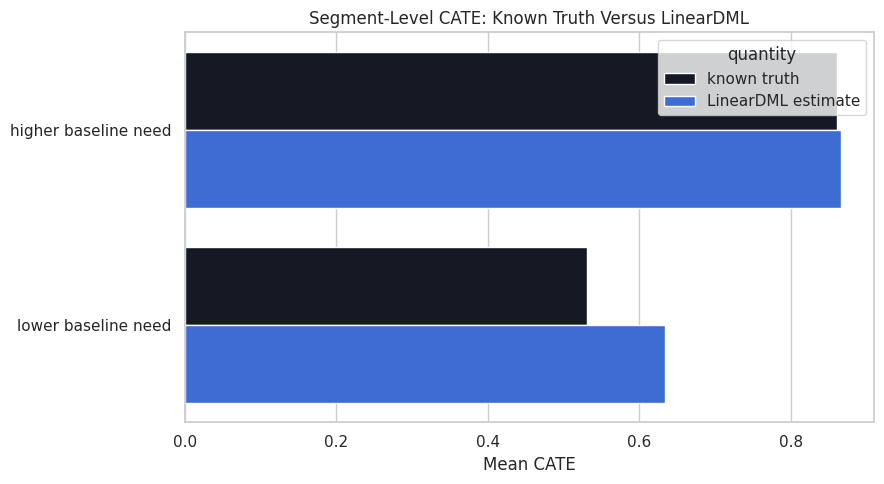

In [17]:
segment_plot_df = segment_summary.melt(
    id_vars="segment",
    value_vars=["true_cate_mean", "estimated_cate_mean"],
    var_name="quantity",
    value_name="cate_mean",
)
segment_plot_df["quantity"] = segment_plot_df["quantity"].replace(
    {"true_cate_mean": "known truth", "estimated_cate_mean": "LinearDML estimate"}
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=segment_plot_df,
    x="cate_mean",
    y="segment",
    hue="quantity",
    palette=["#111827", "#2563eb"],
    ax=ax,
)
ax.set_title("Segment-Level CATE: Known Truth Versus LinearDML")
ax.set_xlabel("Mean CATE")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "00_segment_cate_summary.png", dpi=160, bbox_inches="tight")
plt.show()


The segment plot is a preview of the policy-targeting notebooks. CATE models become useful when their rankings and segment patterns support better treatment decisions.

### What the Smoke Test Shows

A successful `LinearDML` run confirms the package works and that the workflow is coherent. It does not prove every causal assumption in a real analysis.

| what it shows | what it does not show |
| --- | --- |
| EconML is installed and importable | The environment is tuned for every advanced estimator. |
| LinearDML can fit the synthetic example data | LinearDML is the best estimator for every CATE problem. |
| The estimated CATE ranking matches known truth in this simulation | Real-data CATE estimates are individually precise. |
| Observed confounding and overlap diagnostics are visible | Unmeasured confounding has been solved. |


This boundary table is important. EconML estimates effects; the credibility of those effects still depends on design, assumptions, overlap, and diagnostics.

For causal interpretation, this is a support check: weak overlap can make an estimator depend on extrapolation instead of comparable treated and control units.
<!-- result-implication-expanded -->


### Tutorial Series Roadmap

The rest of the EconML series will build from this environment tour toward more advanced estimators and decision workflows.

| notebook | topic | main skill |
| --- | --- | --- |
| 01 | CATE foundations | understand ATE versus CATE |
| 02 | Double machine learning basics | understand nuisance residualization |
| 03 | LinearDML and SparseLinearDML | fit interpretable CATE models |
| 04 | CausalForestDML | fit nonlinear forest-based CATE |
| 05 | DRLearner | use doubly robust pseudo-outcomes |
| 06 | Meta-learners | compare S, T, and X learners |
| 07 | Policy targeting | turn CATE into treatment rules |
| 08 | Explanation and segments | summarize what drives effect heterogeneity |
| 09 | Uncertainty | use intervals and uncertainty-aware decisions |
| 10 | Multiple and continuous treatments | move beyond binary treatment |
| 11 | IV estimators | handle endogenous treatment with instruments |
| 12 | Panel or longitudinal extensions | reason about repeated observations |
| 13 | Estimator benchmark | compare estimators on known truth |
| 14 | End-to-end case study | combine estimation, diagnostics, targeting, and reporting |
| 15 | Pitfalls and debugging | avoid leakage, weak overlap, and overclaimed CATE |


The sequence starts with concepts and ends with applied reporting. That shape mirrors how CATE modeling should be learned: assumptions first, estimators second, decisions last.



### Troubleshooting Checklist

The final table gives quick fixes for common EconML setup and workflow issues.

| symptom | likely cause | first check |
| --- | --- | --- |
| EconML import fails | package not installed or Python/dependency mismatch | run `uv add econml` and verify the Python version supported by the installed EconML release |
| estimator fit fails with shape errors | Y, T, X, or W have inconsistent row counts or unexpected dimensions | print array shapes before calling `.fit()` |
| CATE estimates are noisy or extreme | weak overlap, small sample size, or overly flexible final model | plot propensity overlap and summarize CATE by segment |
| treatment model predicts treatment almost perfectly | poor overlap or leakage into treatment features | inspect propensity distributions by treatment group |
| estimated CATE ranking looks implausible | bad effect modifiers, leakage, or nuisance model misspecification | compare segment summaries and run simpler baseline estimators |
| policy targeting looks too good | evaluating policy on the same data used to learn CATE | use held-out data or doubly robust policy evaluation where possible |


The checklist is deliberately practical. Many EconML issues are data-role, shape, overlap, or leakage issues rather than exotic estimator failures.

For causal interpretation, this is a support check: weak overlap can make an estimator depend on extrapolation instead of comparable treated and control units.
<!-- result-implication-expanded -->


### Final Summary

This environment tour confirmed that EconML is installed, mapped the major estimator families, created a reusable heterogeneous-effect example dataset, and ran a first `LinearDML` smoke test.

Key takeaways:

- EconML is mainly an estimation toolkit for treatment effects, especially CATE.
- The standard data roles are `Y`, `T`, `X`, and `W`.
- CATE work needs overlap diagnostics, nuisance-model thinking, and careful reporting.
- A working estimator call is only the beginning; later notebooks will focus on estimator choice, diagnostics, uncertainty, and treatment policies.

The next notebook introduces CATE foundations and potential-outcomes language before moving deeper into EconML estimators.